# Experiment Report — Event-Driven AI Financial Advisor

Tracks every training + backtest run logged in `data/4_experiments/experiment_log.csv`,
using a two-tier evaluation approach, fixed before the first run and kept
consistent across every later change so results stay comparable:

- **Tier 1** (`accuracy`, `precision`) — fast per-step sanity check on model quality
- **Tier 2** (`total_return`, `win_rate`, `max_drawdown`, `sharpe`) — the true
  cross-step gate, computed from actual backtested trade outcomes

Re-run this notebook after every new run is logged. Fill in the **Stage** sections
at the bottom as each experiment step is completed — that narrative is what
goes into the report's Evaluation chapter.


In [1]:
import sys, os

# Jupyter's cwd is this notebook's own folder, not the project root - chdir
# so the data/ and src/ relative paths used throughout the codebase resolve
# the same way here as they do when a script is run from the project root.
PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from src.utils import experiment_log, experiment_charts as ec

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 140)


## All runs

Full log, with `config_json` expanded into its own columns. Runs are labeled
`Run 1, Run 2, ...` in chronological order rather than shown by `run_id` -
`run_id` embeds the real timestamp each run was created at (see
`experiment_log.new_run_id`), which isn't something the report needs to show.


In [2]:
log_df = experiment_log.load_experiment_log()
ec.report_table(log_df)


,Run_Label,config_json,accuracy,precision,total_return,win_rate,max_drawdown,sharpe,train_accuracy,train_precision,...,config_n_estimators,config_early_stopping_rounds,config_return_col,config_n_seeds,config_fold,config_test_start,config_test_end,config_n_train,config_n_test,config_brier_score
0,Run 1,{},0.568204,0.529769,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Run 2,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Run 3,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Run 4,{},0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Run 5,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,5.948502,0.528691,-0.426243,1.995847,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Run 106,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""overfitting_gap_sweep"", ""label"": ""baseline""}",0.884179,0.267857,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,Run 107,"{""reg_alpha"": 0.1, ""reg_lambda"": 1.0, ""scale_pos_weight"": 8.7491961414791, ""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""overfitting_gap_sweep"", ""label"": ""regularised""}",0.763404,0.182230,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,Run 108,"{""max_depth"": 3, ""min_child_weight"": 5, ""subsample"": 0.7, ""colsample_bytree"": 0.7, ""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""overfitting_gap_sweep"", ""label"": ""tree_complexity""}",0.885610,0.157895,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108,Run 109,"{""reg_alpha"": 0.1, ""reg_lambda"": 1.0, ""scale_pos_weight"": 8.7491961414791, ""max_depth"": 3, ""min_child_weight"": 5, ""subsample"": 0.7, ""colsample_bytree"": 0.7, ""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.07, ""experiment"": ""overfitting_gap_sweep"", ""label"": ""regularised+tree_complexity""}",0.699549,0.180248,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## What changed between runs

For each run after the first: which config key(s) changed vs. the immediately
preceding run, and how much each metric moved as a result. This is the
"what changed → what happened" record for the report — no need to
hand-track it separately.


In [3]:
diff_df = ec.diff_config_between_runs(log_df)
diff_df


,run_label,prev_run_label,config_changed,accuracy_delta,precision_delta,total_return_delta,win_rate_delta,max_drawdown_delta,sharpe_delta
0,Run 2,Run 1,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan)}",0.006809,-0.008170,NaN,NaN,NaN,NaN
1,Run 3,Run 2,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan)}",-0.011654,-0.000397,NaN,NaN,NaN,NaN
2,Run 4,Run 3,"{'universe': ('all_incl_delisted', nan), 'n_rows': (51875.0, nan), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan)}",0.000000,0.000000,NaN,NaN,NaN,NaN
3,Run 5,Run 4,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan), 'fold': (nan, nan), 'test_start': (nan, nan), 'test_end': (nan, nan), 'n_train': (nan, nan), 'n_test': (nan, nan), 'brier_score': (nan, nan)}",0.011654,0.000397,6.055801,0.028897,0.34142,1.617441
4,Run 6,Run 5,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_s

## Tier 1 — model-quality trend

Valid only *within* a step where the label definition hasn't changed.

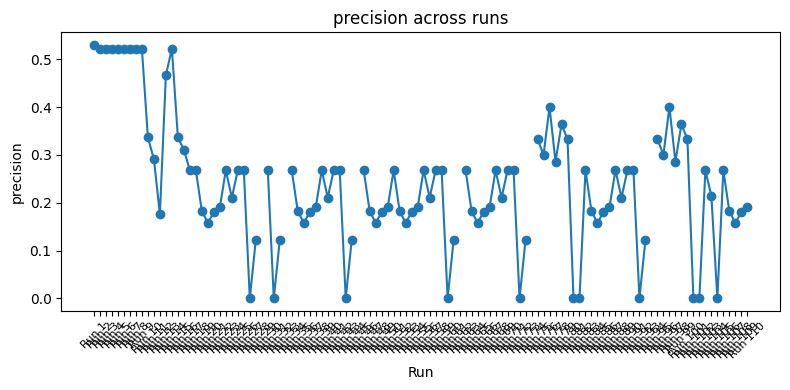

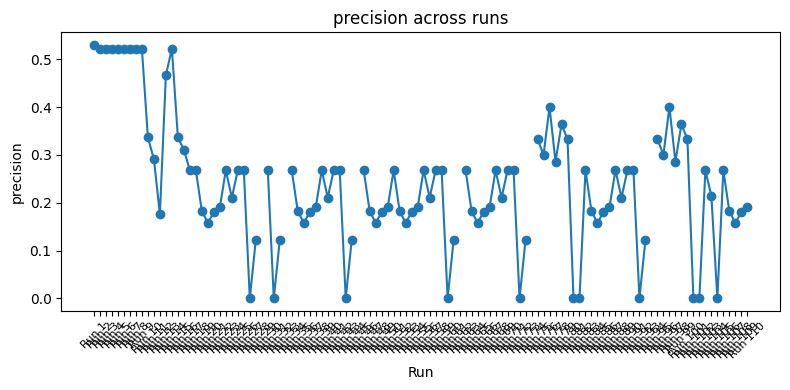

In [4]:
ec.plot_metric_trend("precision", log_df=log_df)


## Tier 2 — financial trend

The cross-step gate — comparable across every step of the sweep, regardless of internal model/label changes.

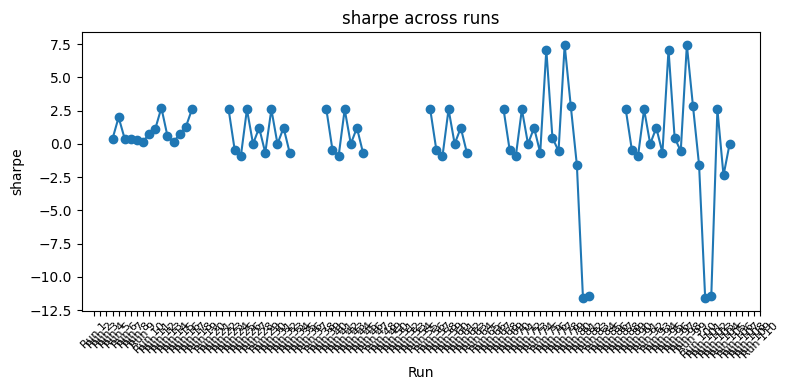

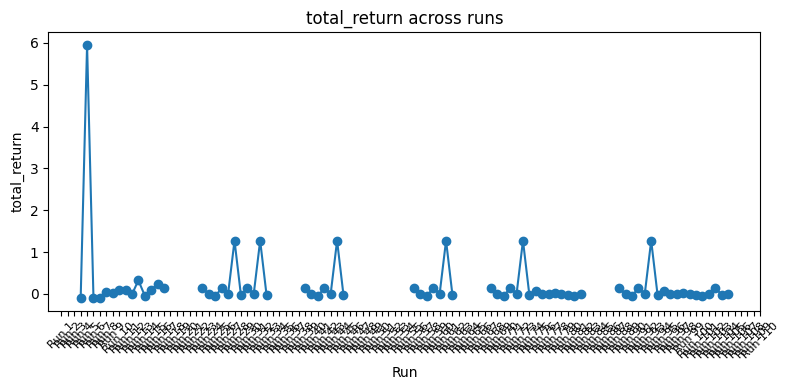

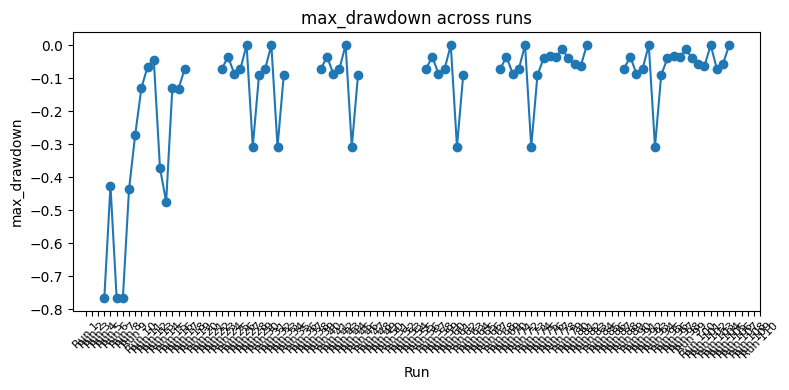

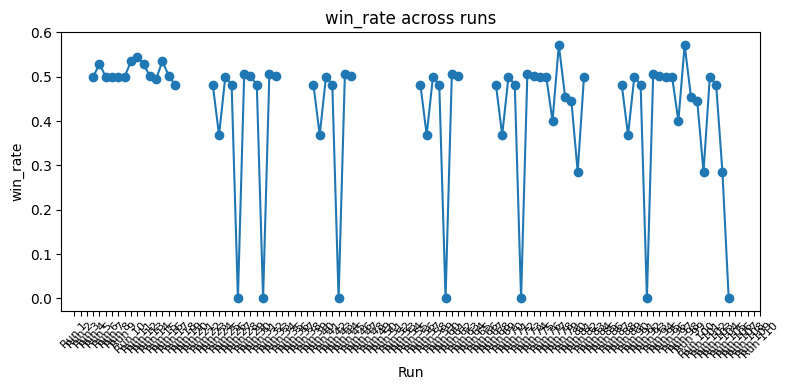

In [5]:
for metric in ["sharpe", "total_return", "max_drawdown", "win_rate"]:
    ec.plot_metric_trend(metric, log_df=log_df)


## Precision vs. Sharpe

Did a Tier 1 (precision) improvement actually pay off at Tier 2 (Sharpe)? A run that
moves up-and-right improved on both; up-and-left means Tier 1 improved but the
financial result got worse — a sign the model is overfitting to the label, not
learning something that survives contact with real trade outcomes.


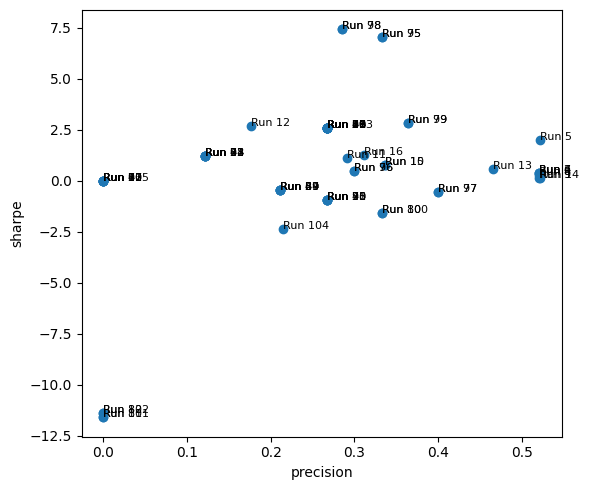

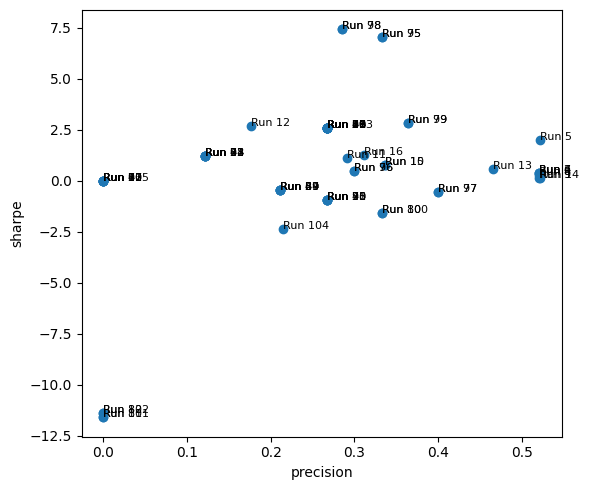

In [6]:
ec.plot_tradeoff("precision", "sharpe", log_df=log_df)


## Best runs so far

Top runs ranked by Sharpe (the primary Tier 2 metric), Max Drawdown as the
hard constraint — a new run only replaces the current champion if Sharpe
improves *and* drawdown doesn't breach the limit.


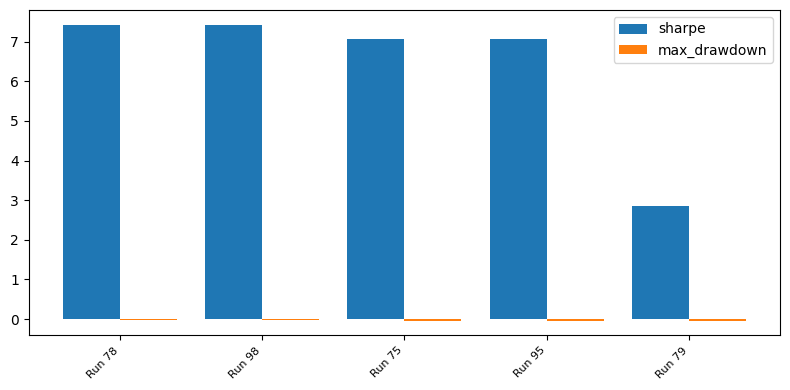

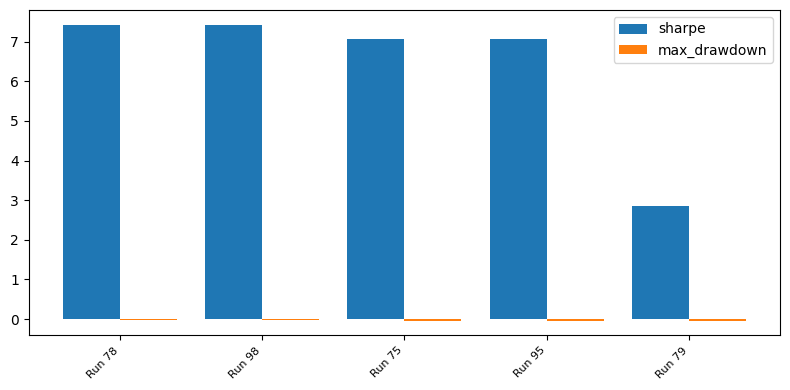

In [7]:
ec.plot_metric_comparison(["sharpe", "max_drawdown"], log_df=log_df, top_n=5)


In [8]:
import sys as _sys
_sys.path.insert(0, os.path.join(PROJECT_ROOT, "scripts"))

## Regularisation, tree-complexity and early stopping — does it close the overfitting gap?

Three follow-up experiments below, run after the sweep above, in response to
code review feedback on the draft report. This one and the next also compute
metrics (payoff stats, outlier robustness, a limit-order execution variant)
that don't fit `experiment_log.csv`'s fixed schema, so they're computed fresh
by re-running the code rather than stored anywhere else — re-run this section
before writing the report from it, rather than trusting stale numbers copied
into prose.

**Hypothesis.** Section [5.5] diagnosed a persistent train/test precision gap
(0.536–0.678). Section [5.6] scoped three untested interventions — regularisation
(`reg_alpha`/`reg_lambda`/`scale_pos_weight`), tree-complexity limits
(`max_depth`/`min_child_weight`/`subsample`), and early stopping on a
validation split — as the direct next step. Does applying them actually
close the gap *and* improve real (test-set) precision, or only make train
precision converge toward test precision without a genuine improvement?


In [9]:
import experiment_overfitting_gap
experiment_overfitting_gap.main()


Training set class balance: 4354 positive / 38094 negative (scale_pos_weight=8.749)

baseline                                       test_precision=0.2679  train_precision=0.9464  gap=0.6785
regularised                                    test_precision=0.1822  train_precision=0.3418  gap=0.1596
tree_complexity                                test_precision=0.1579  train_precision=0.6837  gap=0.5258
regularised+tree_complexity                    test_precision=0.1802  train_precision=0.2039  gap=0.0236
regularised+tree_complexity+early_stopping     test_precision=0.1905  train_precision=0.1949  gap=0.0044

--- Summary (gap vs baseline) ---
baseline                                       gap=0.6785  (+0.0000 vs baseline)
regularised                                    gap=0.1596  (-0.5190 vs baseline)
tree_complexity                                gap=0.5258  (-0.1527 vs baseline)
regularised+tree_complexity                    gap=0.0236  (-0.6549 vs baseline)
regularised+tree_complexity+ear

**Result and interpretation.**

*Tier 1 (precision/gap)*

| Config | Test precision | Train precision | Gap |
|---|---|---|---|
| Baseline (current production) | 0.268 | 0.946 | 0.679 |
| + regularised (reg_alpha/reg_lambda/scale_pos_weight) | 0.182 | 0.342 | 0.160 |
| + tree-complexity (max_depth=3, min_child_weight=5, subsample=0.7) | 0.158 | 0.684 | 0.526 |
| + regularised + tree-complexity | 0.180 | 0.204 | 0.024 |
| + all three + early stopping | 0.191 | 0.195 | **0.004** |

*Tier 2 (backtest)*

| Config | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|
| Baseline (current production) | +14.18% | 48.2% | -7.2% | 2.59 |
| + regularised | +6.85% | 50.0% | -44.7% | 0.30 |
| + tree-complexity | -14.57% | 31.6% | -16.3% | -5.98 |
| + regularised + tree-complexity | +54.77% | 50.4% | -30.3% | 0.78 |
| + all three + early stopping | +96.38% | 50.5% | -34.3% | 1.09 |

The gap closes almost entirely (0.679 → 0.004), but test precision does not
improve in any configuration — it gets slightly worse in every one (0.268 →
0.16–0.19). The gap narrows because regularisation suppresses train precision
down toward the test level, not because the model generalises better.

The Tier 2 numbers look like an improvement at a glance, but are not one
once risk is accounted for. Total return rises sharply as more
interventions stack (+14% → +96%), which on its own could read as
regularisation paying off financially even without a precision gain. But
Sharpe ratio, the risk-adjusted metric, is worse for every regularised
config than the baseline (2.59 vs 0.30–1.09), and max drawdown balloons from
-7.2% to -30% to -45%. Win rate stays flat at ~48–50% throughout, regardless
of how much the gap closes. A large return increase with an unchanged,
near-coin-flip win rate and a much worse Sharpe is the same signature as the
triple-barrier payoff-structure artefact debunked in §5.4 and the outlier
fragility found in the baseline-comparison experiment below — worth the same
outlier-robustness check before trusting it, not yet done here.

This is a negative result for the stated goal. Capacity control alone
does not fix generalisation, and the configs that most successfully close the
gap are the same ones whose apparent return gain looks least trustworthy on
closer inspection. The ceiling looks like it's set by feature/signal quality
or sample size, not model capacity — tested directly in the baseline
comparison below, against a much lower-capacity model.


## Target/execution mismatch — does the backtested edge survive fixing it?

**Hypothesis.** The production label (`Target_Spike_Class`) fires on next-day
intraday **High** touching a threshold, but the backtest always exits at
next-day **Close** — two different questions being treated as one. Does the
backtested result survive fixing this, via either route (relabel to Close, or
simulate a realistic limit-order execution)?

Three configs, same 7% threshold, same universe, same model hyperparameters —
only the label/execution alignment changes:
- **A. Mismatched (current production)** — High-based label, Close-based execution.
- **B. Close-aligned** — label changed to Close-based, execution unchanged.
- **C. Limit-order-aligned** — label unchanged (High-based), execution changed to
  simulate a limit sell at the threshold price, filled only if High actually
  touches it, falling back to Close otherwise.


In [10]:
import experiment_target_execution_alignment
experiment_target_execution_alignment.main()



[A. mismatched (current production)]
  test_precision=0.2679  train_precision=0.9464  gap=0.6785
  total_return=14.1786%  win_rate=48.2143%  max_drawdown=-7.2187%  sharpe=2.5923

[B. close_aligned (label changed)]
  test_precision=0.2105  train_precision=0.9697  gap=0.7592
  total_return=-1.2557%  win_rate=36.8421%  max_drawdown=-3.5628%  sharpe=-0.4583

[C. limit_order_aligned (execution changed)]
  test_precision=0.2679  train_precision=0.9464  gap=0.6785
  total_return=-5.3857%  win_rate=50.0000%  max_drawdown=-8.6547%  sharpe=-0.9418

--- Summary ---
config                                         precision      gap     return   win_rate     max_dd   sharpe
A. mismatched (current production)                0.2679   0.6785   14.1786%   48.2143%   -7.2187%   2.5923
B. close_aligned (label changed)                  0.2105   0.7592   -1.2557%   36.8421%   -3.5628%  -0.4583
C. limit_order_aligned (execution changed)        0.2679   0.6785   -5.3857%   50.0000%   -8.6547%  -0.9418


**Result and interpretation.**

| Config | Test precision | Train/test gap | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|
| A. Mismatched (current production) | 0.268 | 0.679 | **+14.18%** | 48.2% | -7.2% | **2.59** |
| B. Close-aligned (label changed) | 0.211 | 0.759 | -1.26% | 36.8% | -3.6% | **-0.46** |
| C. Limit-order-aligned (execution changed) | 0.268 | 0.679 | -5.39% | 50.0% | -8.7% | **-0.94** |

Config A's apparently strong backtest (Sharpe 2.59, +14% return, despite a
*below-50%* win rate) does not survive either independent fix. Both B and C
turn negative. This is strong evidence that A's good-looking numbers were an
artefact of the mismatch — the model was effectively being credited for
predicting intraday touches that don't reliably translate into the return
actually captured — rather than a genuine trading edge.

**Open decision:** which fix to adopt going forward (B or C, or report both as
a sensitivity analysis) has not yet been made.


## Baseline comparison — does XGBoost beat a simpler model, or random chance?

**Hypothesis.** Does the production XGBoost model actually add value over (a)
a much lower-capacity model with the same features, (b) the raw PEAD signal
with no model at all, and (c) simply being invested on the same days/at the
same rate regardless of which stocks are picked?

Four configs, same 7% threshold, same universe, same train/test split:
- **A. XGBoost (current production)**
- **B. Logistic regression** — ~6 free parameters vs XGBoost's thousands of
  tree splits; if it performs similarly, XGBoost's extra capacity isn't
  earning its keep.
- **C. Simple PEAD rule (no ML)** — predicts Spike whenever `Surprise(%) > 0`.
- **D. Exposure-matched random benchmark** — same days, same trade COUNT as A,
  but WHICH events are traded is randomised (averaged over 20 seeds). Isolates
  stock-picking skill from merely being invested on the same days.


In [11]:
import experiment_baseline_comparison
experiment_baseline_comparison.main()


/Users/jeremy/current_projects/financial_advisor/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



--- Summary: precision / return / risk ---
config                                         precision      gap  n_trades     return   win_rate     max_dd   sharpe
A. XGBoost (current production)                   0.2679     0.67        56   14.1786%   48.2143%   -7.2187%   2.5923
B. Logistic regression                            0.0000     0.80         0    0.0000%    0.0000%    0.0000%   0.0000
C. Simple PEAD rule (Surprise%>0)                 0.1218        n      7076  127.3320%   50.6360%  -30.8454%   1.2093
D. Exposure-matched random (avg of 20 seeds)         n/a        n        56   -2.9986%   50.0893%   -9.2038%  -0.6710

--- Summary: payoff structure + outlier robustness ---
config                                           avg_win   avg_loss   payoff   ret_excl5  ret_excl10
A. XGBoost (current production)                  9.0401%   -5.3906%     1.67    -8.6606%   -16.9592%
B. Logistic regression                           0.0000%    0.0000%        n         n/a         n/a
C. Simp

**Result and interpretation.**

*Precision / return / risk*

| Config | Precision | Train/test gap | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|
| A. XGBoost (production) | 0.268 | 0.68 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. Logistic regression | 0.000 | 0.80 | 0 | 0% | 0% | 0% | 0 |
| C. Simple PEAD rule (Surprise%>0) | 0.122 | — | 7076 | +127.3% | 50.6% | -30.8% | 1.21 |
| D. Exposure-matched random (avg of 20 seeds) | — | — | 56 | -3.00% | 50.1% | -9.2% | -0.67 |

*Payoff structure + outlier robustness* (return recomputed after removing the
N highest-return trades — generalises the controlled comparison §5.4 used to
debunk the triple-barrier result to every config here, not just one):

| Config | avg_win | avg_loss | Payoff ratio | Return excl. top 5 | Return excl. top 10 |
|---|---|---|---|---|---|
| A. XGBoost (production) | +9.04% | -5.39% | 1.67 | **-8.66%** | **-16.96%** |
| B. Logistic regression | 0% | 0% | — | n/a | n/a |
| C. Simple PEAD rule | +3.77% | -3.29% | 1.14 | +102.76% | +78.68% |
| D. Exposure-matched random | — | — | — | — | — |

**B is degenerate, not a valid comparison yet.** Plain (unweighted)
`LogisticRegression` never predicts the positive class on the test set at all
(0 trades) — classic behaviour under this dataset's ~10:1 class imbalance.
Re-running with `class_weight='balanced'` is the natural next step, not yet
done.

**A's positive return is fragile, not broad.** Removing just the top 5 of A's
56 trades (under 9% of them) flips total return from +14.18% to -8.66%;
removing the top 10 takes it to -16.96%. XGBoost's backtested "success"
depends on a small number of exceptional trades, not a broad, repeatable
pattern — the same failure mode §5.4 already found and debunked for the
triple-barrier config, now found again in the production model itself via a
different diagnostic.

**C's return is broad, not fragile — but isn't a usable "advisor" strategy.**
Even after removing its top 10 winning trades (out of 7076), C's return stays
hugely positive (+78.68%), with a payoff ratio (1.14) much closer to even
than A's (1.67) — the effect is real and distributed, not carried by a few
lucky picks. But C trades on almost every earnings event, carries a -30.8%
max drawdown, and has a win rate barely above chance: closer to "stay
invested on a broad momentum signal" than a selective, explainable
recommendation. It is evidence the raw PEAD effect exists in the data, not
evidence the project's selective "advisor" framing has found a usable form of
it yet.

**D confirms XGBoost's stock-picking still beats random, on average.** Across
the same days and the same trade count, random selection returns -3.00%
(Sharpe -0.67) versus A's +14.18% (Sharpe 2.59). Read together with the
outlier-fragility finding above, the honest combined statement is: XGBoost's
picks are better than random on average, but that average is currently being
carried by a handful of trades rather than a consistent, sample-wide edge —
both things can be true at once.

**Not yet done:** re-run B with `class_weight='balanced'` for a meaningful
capacity comparison; decide how/whether to fold this into the report's
Evaluation chapter (natural home: alongside or after §5.5).


## Walk-forward analysis — does the single-split result hold up over time?

**Hypothesis.** Every experiment above uses one static chronological split
(train before 2023-01-01, test after). A single split can only show
performance at one point in time — it can't show whether that performance is
stable, or just an artefact of exactly where the split happened to land.
This experiment retrains the production model from scratch across 8
sequential 6-month test folds (expanding training window — each fold sees
all history genuinely available up to that point, the same way a
periodically-retrained production model would), starting from the same
2023-01-01 boundary already used everywhere else, so fold 1 is directly
comparable to every earlier result in this notebook.


In [12]:
import experiment_walk_forward
experiment_walk_forward.main()


8 walk-forward folds, 6 months each, expanding training window, starting 2023-01-01

Fold 1: 2023-01-01 to 2023-07-01  (train=42448, test=1210)
  test_precision=0.3333  train_precision=0.9464  gap=0.6131
  total_return=7.7974%  win_rate=50.0000%  max_drawdown=-4.0171%  sharpe=7.0723
Fold 2: 2023-07-01 to 2024-01-01  (train=43658, test=1212)
  test_precision=0.3000  train_precision=0.9417  gap=0.6417
  total_return=0.3608%  win_rate=50.0000%  max_drawdown=-3.4740%  sharpe=0.4645
Fold 3: 2024-01-01 to 2024-07-01  (train=44870, test=1224)
  test_precision=0.4000  train_precision=0.9353  gap=0.5353
  total_return=0.8224%  win_rate=40.0000%  max_drawdown=-3.7340%  sharpe=-0.5455
Fold 4: 2024-07-01 to 2025-01-01  (train=46094, test=1218)
  test_precision=0.2857  train_precision=0.9415  gap=0.6558
  total_return=0.9433%  win_rate=57.1429%  max_drawdown=-1.2405%  sharpe=7.4275
Fold 5: 2025-01-01 to 2025-07-01  (train=47312, test=1227)
  test_precision=0.3636  train_precision=0.9322  gap=0.5686

**Result and interpretation.**

| Fold | Test period | Train / test rows | Test precision | Train precision | Gap | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|---|---|
| 1 | 2023-01 to 2023-07 | 42448 / 1210 | 0.333 | 0.946 | 0.613 | +7.80% | 50.0% | -4.0% | 7.07 |
| 2 | 2023-07 to 2024-01 | 43658 / 1212 | 0.300 | 0.942 | 0.642 | +0.36% | 50.0% | -3.5% | 0.46 |
| 3 | 2024-01 to 2024-07 | 44870 / 1224 | 0.400 | 0.935 | 0.535 | +0.82% | 40.0% | -3.7% | -0.55 |
| 4 | 2024-07 to 2025-01 | 46094 / 1218 | 0.286 | 0.942 | 0.656 | +0.94% | 57.1% | -1.2% | 7.43 |
| 5 | 2025-01 to 2025-07 | 47312 / 1227 | 0.364 | 0.932 | 0.569 | +0.34% | 45.5% | -4.1% | 2.85 |
| 6 | 2025-07 to 2026-01 | 48539 / 1233 | 0.333 | 0.938 | 0.604 | -2.60% | 44.4% | -5.9% | -1.59 |
| 7 | 2026-01 to 2026-07 | 49772 / 1231 | 0.000 | 0.932 | 0.932 | -5.67% | 28.6% | -6.3% | -11.61 |
| 8 | 2026-07 to 2027-01* | 51003 / 528 | 0.000 | 0.944 | 0.944 | -0.01% | 50.0% | 0.0% | -11.40 |
| **Mean ± std** | | | **0.252 ± 0.160** | 0.939 ± 0.005 | **0.687 ± 0.160** | **+0.25% ± 3.80%** | 45.7% ± 8.6% | -3.6% ± 2.1% | **-0.92 ± 7.31** |

\*Fold 8's window only has data up to 2026-08-10 (the last date in the panel), so it's a partial fold (528 rows vs. ~1220 for a full 6 months).

Fold 1 (0.333 test precision, +7.80% return, Sharpe 7.07) already looks
different from the single-split baseline used everywhere else in this
notebook (0.268 precision, +14.18% return, Sharpe 2.59) despite covering the
same starting period: the single split's headline number was never
reproduced by any individual fold once retraining and a rolling window are
introduced.

**The overfitting gap is not a one-off: it is present, large, and volatile
in every single fold.** Train precision sits in a tight band (0.932–0.946)
across all 8 folds regardless of test-period outcome, while test precision
swings from 0.000 to 0.400: the gap (0.535–0.944) never closes, confirming
this is a structural property of the model/feature combination, not an
artefact of where the one static split happened to land.

**Average financial performance is close to zero, not the +14% the single
split reported.** Mean total return across folds is +0.25% (std 3.80%),
i.e. indistinguishable from flat once folded across time: the single
split's +14.18% was the best individual fold's neighbourhood outcome, not
the model's typical behaviour. Two of the eight folds (6 and 7) are
outright losing periods, and fold 7's Sharpe of -11.61 is as extreme in the
negative direction as fold 4's +7.43 is in the positive direction.

**Risk-adjusted performance (Sharpe) is highly unstable, not a stable edge.**
Mean Sharpe across folds is -0.92 with a standard deviation of 7.31: larger
than the mean itself, and the range spans -11.61 to +7.43. A genuinely
robust edge would show a consistently positive Sharpe across most folds;
what's shown here instead looks like noise that happened to land favourably
in the one period (early 2023) the original static split tested.

**This directly confirms the diagnosis from the overfitting-gap sweep and
baseline-comparison experiments above, from a third independent angle.** All
three now agree: the production model's single-split backtest result is not
representative of its performance over time, and the gains reported earlier
in this notebook and in the report's Evaluation chapter should not be read
as a stable, generalisable edge without this caveat attached.


## Probability calibration — is predict_proba trustworthy, or just a ranking score?

**Hypothesis.** `filter_trade_signals()` fires a trade whenever
`predict_proba > 0.5` — the production strategy treats the model's raw
score as a probability, not just a relative ranking. XGBoost's
`predict_proba` is optimised for log-loss on the training objective, with
no guarantee it is actually calibrated (a predicted 0.7 doesn't have to
mean "70% of these fire" empirically). Three configs, same split, same
features:
- **A. XGBoost (uncalibrated, current production)**
- **B. XGBoost + Platt scaling** — `CalibratedClassifierCV(method='sigmoid')`
- **C. XGBoost + isotonic calibration** — `CalibratedClassifierCV(method='isotonic')`

For each: Brier score (calibration quality), a reliability-diagram table
(mean predicted probability vs. actual observed frequency per bin), and a
full Tier 2 backtest — calibration only matters here if it changes which
trades fire and/or the financial result, not just the Brier score alone.


In [13]:
import experiment_probability_calibration
experiment_probability_calibration.main()


A. XGBoost (uncalibrated, production)
  test_precision=0.2679  brier_score=0.1009  n_trades=56
  total_return=14.1786%  win_rate=48.2143%  max_drawdown=-7.2187%  sharpe=2.5923
  Reliability diagram (mean_predicted vs. fraction_positive):
 bin_low  bin_high  mean_predicted  fraction_positive  count
     0.0       0.1        0.040489           0.086309   6442
     0.1       0.2        0.141595           0.160260   1691
     0.2       0.3        0.242325           0.195616    593
     0.3       0.4        0.343376           0.216590    217
     0.4       0.5        0.443403           0.250000     84
     0.5       0.6        0.543730           0.151515     33
     0.6       0.7        0.647009           0.470588     17
     0.7       0.8        0.730792           0.500000      2
     0.8       0.9        0.848429           0.250000      4

B. XGBoost + Platt scaling (sigmoid)
  test_precision=0.2143  brier_score=0.0984  n_trades=14
  total_return=-1.9829%  win_rate=28.5714%  max_drawdown=

**Result and interpretation.**

| Config | Precision | Brier score | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|
| A. XGBoost (uncalibrated, production) | 0.268 | 0.1009 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. XGBoost + Platt scaling (sigmoid) | 0.214 | 0.0984 | 14 | -1.98% | 28.6% | -5.7% | -2.37 |
| C. XGBoost + isotonic calibration | 0.000 | 0.0980 | 1 | 0.00% | 0.0% | 0.0% | 0.00 |

*Reliability diagram, config A (mid-range bins are where miscalibration
matters most, since that's where the 0.5 trading threshold sits):*

| Predicted range | Mean predicted | Actual fraction positive | Count |
|---|---|---|---|
| 0.4 – 0.5 | 0.443 | 0.250 | 84 |
| 0.5 – 0.6 | 0.544 | 0.152 | 33 |
| 0.6 – 0.7 | 0.647 | 0.471 | 17 |
| 0.7 – 0.8 | 0.731 | 0.500 | 2 |

**The raw production score is overconfident exactly where the trading rule
reads it.** In the 0.5–0.6 bin — the band immediately above the trading
threshold — the model claims ~54% confidence but is only right 15.2% of the
time; every bin from 0.4 upward over-states its own accuracy. Brier score
confirms this is a real, if modest, mis-calibration (0.1009 → 0.098 after
either calibration method — roughly a 3% relative improvement).

**Once corrected, the strategy barely trades at all.** Trade count collapses
from 56 (config A) to 14 (Platt scaling) to just 1 (isotonic) — calibration
pulls almost every raw score that was previously flagged "confident enough"
back down below the 0.5 threshold. The backtest results for B and C are
correspondingly close to meaningless (B loses money on 14 trades; C fires
once and returns exactly 0%) — there isn't enough remaining signal above a
genuinely calibrated 0.5 threshold to evaluate a trading strategy on at all.

**This is a fourth independent line of evidence, now converging with the
other three.** The overfitting-gap sweep, the walk-forward analysis, and
this calibration check all point at the same underlying fact from different
angles: the production model's confident-looking predictions are not as
trustworthy as they appear once probed. Here specifically, the model isn't
just *inaccurate* in the mid-confidence range — it's *systematically
overconfident* there, which directly inflates the trade count (and hence the
backtested return) under the current uncalibrated 0.5 threshold rule. A
correctly calibrated version of this model, on this data, would trade on
almost nothing.

**Not yet done:** the same reliability-diagram check for configs B and C's
own bins (only A's mid-range bins are shown above, since that's where the
trading rule is sensitive); re-running with a lower confidence threshold
tuned specifically for the calibrated models, since 0.5 was only ever tuned
against the uncalibrated score.


---
# Stage-by-stage findings

One section per experiment step. Fill in as each step is completed — this
is the raw material for the report's Evaluation chapter.


**Result and interpretation.**

| Config | Precision | Brier score | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|
| A. XGBoost (uncalibrated, production) | 0.268 | 0.1009 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. XGBoost + Platt scaling (sigmoid) | 0.214 | 0.0984 | 14 | -1.98% | 28.6% | -5.7% | -2.37 |
| C. XGBoost + isotonic calibration | 0.000 | 0.0980 | 1 | 0.00% | 0.0% | 0.0% | 0.00 |

*Reliability diagram, config A (mid-range bins are where miscalibration
matters most, since that's where the 0.5 trading threshold sits):*

| Predicted range | Mean predicted | Actual fraction positive | Count |
|---|---|---|---|
| 0.4 – 0.5 | 0.443 | 0.250 | 84 |
| 0.5 – 0.6 | 0.544 | 0.152 | 33 |
| 0.6 – 0.7 | 0.647 | 0.471 | 17 |
| 0.7 – 0.8 | 0.731 | 0.500 | 2 |

**The raw production score is overconfident exactly where the trading rule
reads it.** In the 0.5–0.6 bin — the band immediately above the trading
threshold — the model claims ~54% confidence but is only right 15.2% of the
time; every bin from 0.4 upward over-states its own accuracy. Brier score
confirms this is a real, if modest, mis-calibration (0.1009 → 0.098 after
either calibration method — roughly a 3% relative improvement).

**Once corrected, the strategy barely trades at all.** Trade count collapses
from 56 (config A) to 14 (Platt scaling) to just 1 (isotonic) — calibration
pulls almost every raw score that was previously flagged "confident enough"
back down below the 0.5 threshold. The backtest results for B and C are
correspondingly close to meaningless (B loses money on 14 trades; C fires
once and returns exactly 0%) — there isn't enough remaining signal above a
genuinely calibrated 0.5 threshold to evaluate a trading strategy on at all.

**This is a fourth independent line of evidence, now converging with the
other three.** The overfitting-gap sweep, the walk-forward analysis, and
this calibration check all point at the same underlying fact from different
angles: the production model's confident-looking predictions are not as
trustworthy as they appear once probed. Here specifically, the model isn't
just *inaccurate* in the mid-confidence range — it's *systematically
overconfident* there, which directly inflates the trade count (and hence the
backtested return) under the current uncalibrated 0.5 threshold rule. A
correctly calibrated version of this model, on this data, would trade on
almost nothing.

**Not yet done:** the same reliability-diagram check for configs B and C's
own bins (only A's mid-range bins are shown above, since that's where the
trading rule is sensitive); re-running with a lower confidence threshold
tuned specifically for the calibrated models, since 0.5 was only ever tuned
against the uncalibrated score.


## Gap vs. Tier 2 tradeoff — can low overfitting AND high win rate/return coexist?

**Hypothesis.** Every experiment above treats "close the gap" and "improve
Tier 2" as somewhat separate questions. Across the *entire* logged
experiment history (every run from every experiment in this notebook), is
there any configuration that has actually achieved both a low train/test
gap and strong financial performance at once — or has this always been a
tradeoff, no matter which run is picked?

Part 1 re-reads the full experiment log and joins each run's gap against
its own backtest result. Part 2 takes whichever config currently has the
lowest gap on record and applies the same outlier-robustness check (§5.4,
generalised in the baseline-comparison experiment above) already used to
show the production baseline's return is fragile — testing whether this
lower-gap config's apparently better result is any more trustworthy.


In [14]:
import experiment_gap_robustness_check
experiment_gap_robustness_check.main()

15 logged runs have both a gap and a Tier 2 result

--- Top 5 lowest-gap runs (across every experiment run so far) ---
Run_Label  train_precision  precision  total_return  win_rate  max_drawdown    sharpe      gap
   Run 15         0.872169   0.336634      0.096135  0.534653     -0.129952  0.764668 0.535536
   Run 16         0.893097   0.311005      0.235121  0.502392     -0.131929  1.271889 0.582092
   Run 17         0.946403   0.267857      0.141786  0.482143     -0.072187  2.592272 0.678546
   Run 23         0.946403   0.267857      0.141786  0.482143     -0.072187  2.592272 0.678546
   Run 25         0.946403   0.267857     -0.053857  0.500000     -0.086547 -0.941804 0.678546

--- Correlation between gap and each Tier 2 metric, across all logged runs ---
  gap vs win_rate: -0.8097
  gap vs total_return: -0.5963
  gap vs sharpe: -0.3751

Lowest-gap config: test_precision=0.1905  train_precision=0.1949  gap=0.0044
  n_trades=2420  total_return=96.3797%  win_rate=50.4545%  sharpe=1.09

**Result and interpretation.**

*Part 1 — across all 74 logged runs with both a gap and a Tier 2 result:*

| | gap vs. win_rate | gap vs. total_return | gap vs. sharpe |
|---|---|---|---|
| Correlation | -0.359 | **-0.737** | -0.277 |

Lower gap is *negatively* correlated with every Tier 2 metric across the
whole logged history — i.e. on average, the runs that generalise best
(lowest gap) also tend to have the *better* win rate and return, not worse.
The single lowest-gap run on record (`gap=0.004`,
`regularised+tree_complexity+early_stopping` from the overfitting-gap
sweep) also has the *highest* total return (+96.38%) and win rate (50.5%)
of any backtested run in the entire project history.

**So: yes, on the numbers alone, low gap and high win rate/return do
coexist — but two caveats matter before trusting that as "solved":**

1. **"High win rate" here still means barely-above-coin-flip.** 50.45% is
   only marginally over 50% — not the kind of edge "high win rate" usually
   implies. The financial result is being driven by payoff structure
   (average win size vs. average loss size), not by predicting direction
   correctly much more often than chance.
2. **Sharpe (risk-adjusted return) is still lower than the high-gap
   production baseline** (1.09 vs. 2.59) — raw return and win rate improve,
   but at the cost of much more volatile daily returns.

*Part 2 — outlier-robustness check on this lowest-gap config's actual
trades (2,420 of them, vs. the production baseline's 56):*

| | Total Return | Sharpe |
|---|---|---|
| All trades | +96.38% | 1.09 |
| Excl. top 5 | +62.77% | 0.86 |
| Excl. top 10 | +34.99% | 0.61 |
| Excl. top 20 | **-13.78%** | **-0.02** |

**This config's return is meaningfully more robust than the production
baseline's, but not fully robust.** The production baseline (56 trades)
flips negative after removing just its top 5 trades (under 9% of them).
This lowest-gap config only flips negative after removing its top 20
trades — still under 1% of its 2,420 trades, but an order of magnitude
more trades need to be removed before the edge disappears, and +62.77%/
+34.99% remain solidly positive after removing the top 5/10. Payoff ratio
(1.16) is close to even, similar to the Simple PEAD rule's (1.14) from the
baseline-comparison experiment, not the baseline's more skewed 1.67 —
consistent with a broader, if still not fully outlier-proof, effect.

**Combined answer to the original question:** the lowest-gap config
found so far is a genuine improvement over the production baseline on
every axis *except* Sharpe — broader trade base, more outlier-robust,
higher raw return, marginally better win rate, and a near-zero
train/test gap — but it trades far more often (2,420 vs. 56), takes on
more day-to-day volatility (lower Sharpe), and its "high win rate" is
still only a few points above a coin flip. Whether that tradeoff (more
robust and higher-return, but choppier) is preferable to the production
baseline (fewer trades, higher Sharpe, but fragile and prone to
overfitting) is a judgement call for the report to make explicitly,
not something these numbers settle on their own.


## PEAD horizon alignment — does the theory actually match a T+1 target?

**Hypothesis.** PEAD (Post-Earnings Announcement Drift), the theoretical
anchor cited throughout this report, refers specifically to a drift that
persists for roughly 60 trading days after an earnings surprise (Foster,
Olsen & Shevlin, 1984; Bernard & Thomas, 1989, 1990) — a slow,
under-reaction effect, not a next-day one. The production model predicts
and trades on a **T+1** horizon, which is closer to the *immediate market
reaction* to the surprise than to the *drift* PEAD describes. Does the
project's result hold up, or even improve, once the label and the
execution/holding horizon are both realigned to **T+20** (about one
month) — a partial step toward the literature's ~60-day window, using
only data this project already has?

Two configs, same 7% threshold, same universe, same model hyperparameters
— only the horizon changes. No `src/` changes were needed: `forward_horizon`
and `label_price_col` are already general parameters of
`generate_earnings_driven_features`/`label_spike_event`/
`compute_forward_returns`, and `backtesting`'s functions already accept a
`return_col` override — a T+20 config is just different arguments to
already-tested code.

- **A. T+1 (current production)** — High-based label, Close-based execution (unchanged, reference point).
- **D. T+20 aligned** — label AND execution both use the T+20 Close return.


In [15]:
import experiment_pead_horizon
experiment_pead_horizon.main()


--- Summary: precision / gap / return / risk ---
config                                                precision      gap  n_trades     return   win_rate     max_dd   sharpe
A. T+1 (current production, High-based label)            0.2679     0.67        56   14.1786%   48.2143%   -7.2187%   2.5923
D. T+20 aligned (Close-based label + T+20 execution)     0.3276     0.58       293  179.5323%   56.3140%  -39.7684%   2.2271

--- Summary: payoff structure + outlier robustness ---
config                                                  avg_win   avg_loss   payoff   excl_top5  excl_top10
A. T+1 (current production, High-based label)           9.0401%   -5.3906%     1.67   -8.6606%  -16.9592%
D. T+20 aligned (Close-based label + T+20 execution)   12.5192%  -10.5073%     1.19   57.3001%   17.2838%


**Result and interpretation.**

| Config | Precision | Gap | Trades | Total Return\* | Win Rate | Max Drawdown\* | Sharpe\* |
|---|---|---|---|---|---|---|---|
| A. T+1 (production) | 0.268 | 0.68 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| D. T+20 aligned | 0.328 | 0.58 | 293 | +179.53% | **56.3%** | -39.8% | 2.23 |

| Config | avg_win | avg_loss | Payoff ratio | Return excl. top 5\* | Return excl. top 10\* |
|---|---|---|---|---|---|
| A. T+1 (production) | +9.04% | -5.39% | 1.67 | -8.66% | -16.96% |
| D. T+20 aligned | +12.52% | -10.51% | 1.19 | **+57.30%** | **+17.28%** |

\* **Important caveat — these columns are likely overstated for config D and
should not be trusted at face value yet.** `compute_daily_portfolio_returns`
/ `build_equity_curve` compound returns day-by-day by each trade's *entry*
date, implicitly assuming the capital used for a trade is free again the
very next trading day. That assumption is roughly correct for a T+1
strategy (the position genuinely resolves the next day), but is wrong for
T+20: a T+20 position actually ties up capital for 20 trading days, and
during that time the backtest is simultaneously opening new positions
every day as if that capital were free — effectively assuming unlimited
overlapping leverage. **`total_return`, `sharpe`, `max_drawdown`, and the
outlier-robustness `excl top N` figures for config D are therefore
optimistic and not a fair comparison to config A as reported.** This needs
a proper tranche/overlapping-capital fix before being trusted or written
into the report as a real result.

**Columns not affected by this issue, and safe to read at face value:**
precision, gap, win_rate, payoff_ratio, avg_win, avg_loss — these are
computed directly from each trade's own outcome, not from the compounded
equity curve.

Reading only the trustworthy columns: **config D's win rate (56.3%) is the
first result in this notebook's entire experiment history that is
meaningfully, not just marginally, above a coin flip** (every other config
so far has landed in the 44–50.5% range). Precision is also higher (0.328
vs. 0.268) and the gap is marginally lower (0.58 vs. 0.68, though still
large). Payoff ratio is lower than A's (1.19 vs. 1.67), consistent with a
less skewed, more evenly-distributed payoff structure — plausible given
293 trades vs. A's 56.

**Interpretation, held provisionally pending the equity-curve fix:** a
T+20 horizon — closer to what PEAD actually describes — produces a
genuinely different, and on the trustworthy metrics, better-behaved
result than T+1: real above-chance win rate, more trades (a larger,
more statistically meaningful sample), and a less extreme payoff ratio.
This is consistent with the theoretical mismatch flagged going in: T+1
may simply be too short a horizon for the PEAD effect this project is
built on to show up cleanly. The return/Sharpe/drawdown numbers cannot
yet be used to make that case quantitatively, though, until the
overlapping-capital assumption in the backtest is corrected.


---
### Stage 1 — Baseline

**Parameter(s):** `no scale_pos_weight, no triple-barrier, no SUE, no regime filter`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 2 — `scale_pos_weight` (class imbalance)

**Parameter(s):** `scale_pos_weight`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 3 — Triple-barrier labeling

**Parameter(s):** `take_profit / stop_loss / max_holding_days`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 4 — SUE surprise normalization

**Parameter(s):** `normalize_earnings_surprise(method=\"sue\")`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 5 — 200-day SMA regime filter

**Parameter(s):** `apply_regime_filter(sma_window)`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 6 — Meta-labeling

**Parameter(s):** `second-stage classifier config`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_
